# Preprocess CAMS data for dust tool

Interpolate CAMS data to EEA station locations, account for the local timezone, and average per day so that the resulting netcdf file is smaller

## Importing modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import time
import requests
import os
import glob
import zipfile
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm
import re
import pyarrow as pa
import pyarrow.parquet as pq
from flox.xarray import xarray_reduce
import dask
from dask.diagnostics import ProgressBar

## Loading data (lazy)

In [2]:
# Load cams dust data
dust_files = glob.glob(os.path.join('CAMS_data', '*dust*.nc'))
cams_dust = xr.open_mfdataset(dust_files, combine='by_coords')
cams_dust = cams_dust.sortby('time')

In [ ]:
#Load observation data
folder_path = './EEA_data'
parquet_files = glob.glob(os.path.join(folder_path, "*.parquet"))
dataframes = [pd.read_parquet(file) for file in parquet_files]
obs = pd.concat(dataframes, ignore_index=True)

# Set Start as datetime
obs['Start'] = pd.to_datetime(obs['Start'])

# Drop unnecessary columns
obs = obs.drop(columns=['End', 'ResultTime', 'Pollutant',
       'Unit', 'AggType', 'DataCapture','FkObservationLog'])

In [ ]:
#Count and filter observation data
print(f"Number of observations before filtering: {len(obs)}")
obs = obs[obs['Validity'] > 0]
print(f"Number of observations after validity filter: {len(obs)}")
obs = obs[obs['Verification'] == 1]
print(f"Number of observations after verification filter: {len(obs)}")

In [ ]:
# Filter for stations with 2024 data
stations_with_2024_data = obs[
    (obs['Start'] >= '2024-01-01') & (obs['Start'] < '2025-01-01')
]['Samplingpoint'].unique()
obs = obs[obs['Samplingpoint'].isin(stations_with_2024_data)]
print(f"Number of observations after filtering for 2024 stations: {len(obs)}")

In [7]:
# Calculate data coverage for each station
#def calculate_data_coverage(df):
#    total_days = 366
#    coverage_stats = df.groupby('Samplingpoint')['Start'].apply(lambda x: x.dt.date.nunique())
#    coverage_stats = coverage_stats.to_frame(name='unique_days')
#    coverage_stats['coverage_percentage'] = (coverage_stats['unique_days'] / total_days) * 100
#    coverage_stats['sufficient_coverage'] = coverage_stats['coverage_percentage'] > 75
#    return coverage_stats

#coverage_stats = calculate_data_coverage(obs)

# Filter stations with sufficient coverage
sufficient_stations = coverage_stats[coverage_stats['sufficient_coverage']].index.tolist()

# Filter obs to only include stations with sufficient coverage
obs = obs[obs['Samplingpoint'].isin(sufficient_stations)].copy()
print(f"\nNumber of observations after filtering for data coverage: {len(obs)}")


Number of observations after filtering for data coverage: 431948


In [8]:
#Load metadata observational data
metadata = pd.read_csv('DataExtract.csv', low_memory = False)

# Retrieve stations from observational data
all_stations = pd.DataFrame({'Samplingpoint': obs['Samplingpoint'].unique()})

# Create dataframe with all stations and their location
metadata['Samplingpoint'] = metadata['Air Quality Station EoI Code'].str[:2] + '/' + metadata['Sampling Point Id']
stations = all_stations.merge(
    metadata[['Samplingpoint', 'Longitude', 'Latitude', 'Altitude','Timezone']], 
    on='Samplingpoint', 
    how='left'
).drop_duplicates(subset=['Samplingpoint'], keep='first')

# Add station coordinates to obs
obs = obs.merge(stations[['Samplingpoint', 'Latitude', 'Longitude','Altitude','Timezone']], 
                on='Samplingpoint', 
                how='left')

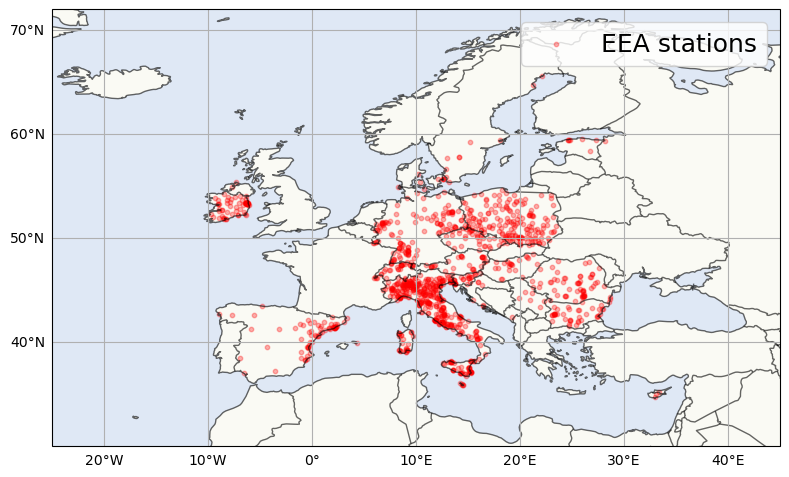

In [9]:
unique_stations = obs['Samplingpoint'].unique()
unique_stations_df = obs[['Samplingpoint', 'Longitude', 'Latitude']].drop_duplicates().reset_index(drop=True)
unique_stations_df

fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax.scatter(unique_stations_df['Longitude'], unique_stations_df['Latitude'], color='red', s=10, alpha=0.3,label='EEA stations',transform=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, alpha=0.6)
ax.add_feature(cfeature.BORDERS, alpha=0.6)
ax.add_feature(cfeature.LAND, alpha=0.3)
ax.add_feature(cfeature.OCEAN, alpha=0.3)
ax.set_extent([-25, 45, 30, 72], crs=ccrs.PlateCarree())

# Add gridlines
gl = ax.gridlines(draw_labels=False, dms=False, x_inline=False, y_inline=False)
gl.bottom_labels = True
gl.left_labels = True

ax.legend(fontsize=18)
plt.tight_layout()
plt.show()

## Preprocess CAMS data

In [ ]:
# Definition to extract timezone
def extract_timezone_offset(tz_string):
    if tz_string == 'UTC':
        return 0
    else:
        return int(tz_string.replace('UTC+', ''))

# Definition to interpolate from closest model gridpoints
def interpolate_local_region(ds, lat, lon, buffer=0.25):
    local_region = ds.sel(
        lat=slice(lat-buffer, lat+buffer),
        lon=slice(lon-buffer, lon+buffer)
    )
    return local_region.interp(lat=lat, lon=lon, method='linear')

# Flag dust for each samplingpoint separately
unique_stations = obs['Samplingpoint'].unique()

datasets = []

for i, station in enumerate(unique_stations):
    print(f"\rProcessing station {i+1}/{len(unique_stations)}", end="")
    
    # Get station coordinates and timezone
    station_obs = obs[obs['Samplingpoint'] == station]
    lat = station_obs['Latitude'].iloc[0]
    lon = station_obs['Longitude'].iloc[0]
    tz_offset = extract_timezone_offset(station_obs['Timezone'].iloc[0])
    
    # Interpolate CAMS data to this station location
    station_cams = interpolate_local_region(cams_dust, lat, lon)
    
    # Convert UTC to local timezone
    station_cams['time_local'] = station_cams['time'] + pd.to_timedelta(tz_offset, unit='h')
    
    # Calculate daily average dust using local timezone
    daily_cams = station_cams.groupby(station_cams['time_local'].dt.date).mean()
    datasets.append(daily_cams)

cams = xr.concat(datasets, dim='time')
cams = cams.sortby('time')

In [10]:
# Prepare arrays of unique station coordinates
unique_stations_df = obs[['Samplingpoint', 'Longitude', 'Latitude', 'Timezone']].drop_duplicates().reset_index(drop=True)

# Interpolate CAMS data to all station locations at once
cams_interp = cams_dust.interp(
    lat=xr.DataArray(unique_stations_df['Latitude'], dims='station'),
    lon=xr.DataArray(unique_stations_df['Longitude'], dims='station')
)

# Add timezone offsets
def extract_timezone_offset_vec(tz_series):
    return tz_series.replace('UTC', 'UTC+0').str.replace('UTC\\+', '', regex=True).astype(int)

tz_offsets = extract_timezone_offset_vec(unique_stations_df['Timezone'])
cams_interp = cams_interp.assign_coords(station=('station', unique_stations_df['Samplingpoint']))

# Convert UTC to local time for each station
cams_interp['time_local'] = cams_interp['time'] + xr.DataArray(
    tz_offsets.values, dims='station'
).astype('timedelta64[h]')

In [11]:
# Create a date coordinate from time_local
date = xr.DataArray(
    cams_interp["time_local"].dt.floor("D").data,
    dims=("time", "station"),
    name="date"
)
cams_interp = cams_interp.assign_coords(date=date)

# Group by date and station, then average over time
cams_daily = cams_interp.groupby("date").mean(dim="time")

In [12]:
cams_daily

<xarray.Dataset> Size: 2MB
Dimensions:  (station: 1145, date: 398)
Coordinates:
    lat      (station) float64 9kB 45.76 45.8 44.02 45.46 ... 41.76 41.35 41.67
    lon      (station) float64 9kB 16.01 15.97 15.52 ... -1.143 -1.653 -0.8711
  * station  (station) object 9kB 'HR/HR_DOC_TYPE_D_SPO_1067' ... 'ES/SP_5029...
  * date     (date) datetime64[ns] 3kB 2023-12-01 2023-12-02 ... 2025-01-01
Data variables:
    dust     (station, date) float32 2MB dask.array<chunksize=(1145, 398), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.7
    Title:        CAMS European air quality interim reanalysis
    Provider:     COPERNICUS European air quality service
    Production:   COPERNICUS Atmosphere Monitoring Service

In [ ]:
cams_daily.load()

## Write netcdf file

In [12]:
# Re-chunk to smaller blocks
cams_daily = cams_daily.chunk({'date': 50, 'station': 50})
print('re-chunked')

with ProgressBar():
    cams_daily.to_netcdf('cams_preproccesed.nc', format='NETCDF4')

re-chunked
[                                        ] | 1% Completed | 47m 22sms

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[######                                  ] | 15% Completed | 83m 23s

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[###########                             ] | 27% Completed | 114m 17s

...

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[#################################       ] | 83% Completed | 4hr 13m

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[#####################################   ] | 92% Completed | 4hr 38m

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [13]:
cams_daily

<xarray.Dataset> Size: 2MB
Dimensions:  (station: 1145, date: 398)
Coordinates:
    lat      (station) float64 9kB dask.array<chunksize=(50,), meta=np.ndarray>
    lon      (station) float64 9kB dask.array<chunksize=(50,), meta=np.ndarray>
  * station  (station) object 9kB 'HR/HR_DOC_TYPE_D_SPO_1067' ... 'ES/SP_5029...
  * date     (date) datetime64[ns] 3kB 2023-12-01 2023-12-02 ... 2025-01-01
Data variables:
    dust     (station, date) float32 2MB dask.array<chunksize=(50, 50), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.7
    Title:        CAMS European air quality interim reanalysis
    Provider:     COPERNICUS European air quality service
    Production:   COPERNICUS Atmosphere Monitoring Service